### import libraries and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [3]:
deliveries=pd.read_csv('deliveries.csv')
matches=pd.read_csv('matches.csv')

In [4]:
deliveries.shape

(260920, 17)

In [5]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [6]:
matches.shape

(1095, 20)

In [7]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [8]:
matches['team1'].value_counts()

team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Punjab Kings                    31
Lucknow Super Giants            23
Pune Warriors                   23
Gujarat Titans                  21
Gujarat Lions                   16
Royal Challengers Bengaluru      9
Kochi Tuskers Kerala             7
Rising Pune Supergiant           7
Rising Pune Supergiants          7
Name: count, dtype: int64

### Data Cleaning

For Teams played for pune as they had 2 team throughout their career.       Hence For analysis purpose we consider them as one

In [9]:
matches['team1'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'}, inplace=True)
matches['team2'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'}, inplace=True)
matches['toss_winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'}, inplace=True)
matches['winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'}, inplace=True)

In [10]:
matches['team1'].value_counts()

team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Punjab Kings                    31
Pune Warriors                   23
Lucknow Super Giants            23
Gujarat Titans                  21
Gujarat Lions                   16
Rising Pune Supergiant          14
Royal Challengers Bengaluru      9
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [11]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Royal Challengers Bangalore    28205
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          1900
Royal Challengers Bengaluru     1818
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64

In [12]:
deliveries['batting_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
deliveries['bowling_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)

In [13]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Royal Challengers Bangalore    28205
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          3480
Royal Challengers Bengaluru     1818
Kochi Tuskers Kerala            1582
Name: count, dtype: int64

In [14]:
deliveries.replace({'Pune Warriors ':'Rising Pune Supergiant'},inplace=True)
matches.replace({'Pune Warriors':'Rising Pune Supergiant'},inplace=True)

In [15]:
deliveries.replace({'Royal Challengers Bangalore':'Royal Challengers Bengaluru'},inplace=True)
matches.replace({'Royal Challengers Bangalore':'Royal Challengers Bengaluru'},inplace=True)

In [16]:
deliveries.replace({'Delhi Daredevils':'Delhi Capitals'},inplace=True)
matches.replace({'Delhi Daredevils':'Delhi Capitals'},inplace=True)

In [17]:
deliveries.replace({'Kings XI Punjab':'Punjab Kings'},inplace=True)
matches.replace({'Kings XI Punjab':'Punjab Kings'},inplace=True)

In [18]:
deliveries.replace({'Gujarat Lions':'Gujarat Titans'},inplace=True)
matches.replace({'Gujarat Lions':'Gujarat Titans'},inplace=True)

In [19]:
matches['city'].isna().sum()

np.int64(51)

In [20]:
matches['method'].value_counts()

method
D/L    21
Name: count, dtype: int64

In [21]:
matches['city'].fillna('Unknown', inplace=True)
matches['method'].fillna('Non D/L',inplace=True)

In [22]:
matches['city'].isna().sum()


np.int64(0)

In [23]:
matches['method'].value_counts()

method
Non D/L    1074
D/L          21
Name: count, dtype: int64

In [24]:
matches.groupby('season')['id'].count()

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: id, dtype: int64

In [25]:
matches['season'].replace({'2007/08': 2008,'2009/10':2010, '2020/21':2020 }, inplace=True)

In [26]:
matches.dtypes

id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object

In [27]:
change_dtype=['result_margin','target_runs','target_overs','super_over']

In [28]:
matches[change_dtype].isnull().sum()

result_margin    19
target_runs       3
target_overs      3
super_over        0
dtype: int64

In [29]:
matches[change_dtype] = matches[change_dtype].apply(pd.to_numeric, errors='coerce')
matches[change_dtype]=matches[change_dtype].astype('float64')


we converted all the null values as 0 for following reasons
1. result_margin=null usually means the match has been tied
2. target_runs & target over = null means the match got cancelled due to any issues(rain interruption, match abandoned, etc )

In [30]:
matches['season']=matches['season'].astype(int)

In [31]:
matches.dtypes

id                   int64
season               int64
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over         float64
method              object
umpire1             object
umpire2             object
dtype: object

### Q1 Sucess rate accoding to the team

In [32]:
match_wins=matches['winner'].value_counts()
match_wins

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Gujarat Titans                  41
Deccan Chargers                 29
Rising Pune Supergiant          27
Lucknow Super Giants            24
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [33]:
matches_played=matches['team1'].value_counts() + matches['team2'].value_counts()
matches_played

Chennai Super Kings            238
Deccan Chargers                 75
Delhi Capitals                 252
Gujarat Titans                  75
Kochi Tuskers Kerala            14
Kolkata Knight Riders          251
Lucknow Super Giants            44
Mumbai Indians                 261
Punjab Kings                   246
Rajasthan Royals               221
Rising Pune Supergiant          76
Royal Challengers Bengaluru    255
Sunrisers Hyderabad            182
Name: count, dtype: int64

In [34]:
win_rate=(match_wins/matches_played).sort_values(ascending=False)
win_rate

Chennai Super Kings            0.579832
Mumbai Indians                 0.551724
Gujarat Titans                 0.546667
Lucknow Super Giants           0.545455
Kolkata Knight Riders          0.521912
Rajasthan Royals               0.506787
Sunrisers Hyderabad            0.483516
Royal Challengers Bengaluru    0.482353
Delhi Capitals                 0.456349
Punjab Kings                   0.455285
Kochi Tuskers Kerala           0.428571
Deccan Chargers                0.386667
Rising Pune Supergiant         0.355263
Name: count, dtype: float64

In [35]:
win_perc=(win_rate*100).round(2)
win_perc



Chennai Super Kings            57.98
Mumbai Indians                 55.17
Gujarat Titans                 54.67
Lucknow Super Giants           54.55
Kolkata Knight Riders          52.19
Rajasthan Royals               50.68
Sunrisers Hyderabad            48.35
Royal Challengers Bengaluru    48.24
Delhi Capitals                 45.63
Punjab Kings                   45.53
Kochi Tuskers Kerala           42.86
Deccan Chargers                38.67
Rising Pune Supergiant         35.53
Name: count, dtype: float64

In [36]:
short_forms = pd.DataFrame({
    'team_name': [
        'Chennai Super Kings',
        'Mumbai Indians',
        'Royal Challengers Bengaluru',
        'Kolkata Knight Riders',
        'Delhi Capitals',
        'Punjab Kings',
        'Rajasthan Royals',
        'Sunrisers Hyderabad',
        'Lucknow Super Giants',
        'Gujarat Titans',
        'Kochi Tuskers Kerala',
        'Deccan Chargers',
        'Rising Pune Supergiant'
    ],
    'team_code': [
        'CSK','MI','RCB','KKR','DC','PBKS','RR','SRH','LSG','GT','KTK','DCG','RPS'
    ]
})
short_forms

,team_name,team_code
0,Chennai Super Kings,CSK
1,Mumbai Indians,MI
2,Royal Challengers Bengaluru,RCB
3,Kolkata Knight Riders,KKR
4,Delhi Capitals,DC
5,Punjab Kings,PBKS
6,Rajasthan Royals,RR
7,Sunrisers Hyderabad,SRH
8,Lucknow Super Giants,LSG
9,Gujarat Titans,GT


In [37]:
def merge_short_names(series, value_name):
    
    df = series.reset_index()
    
    df = df.rename(columns={
        df.columns[0]: 'team_name',
        df.columns[1]: value_name
    })
    
    df = df.merge(short_forms, on='team_name', how='left')
    
    return df

In [38]:
win_df=merge_short_names(win_perc,'win_rate')
win_df

,team_name,win_rate,team_code
0,Chennai Super Kings,57.98,CSK
1,Mumbai Indians,55.17,MI
2,Gujarat Titans,54.67,GT
3,Lucknow Super Giants,54.55,LSG
4,Kolkata Knight Riders,52.19,KKR
5,Rajasthan Royals,50.68,RR
6,Sunrisers Hyderabad,48.35,SRH
7,Royal Challengers Bengaluru,48.24,RCB
8,Delhi Capitals,45.63,DC
9,Punjab Kings,45.53,PBKS


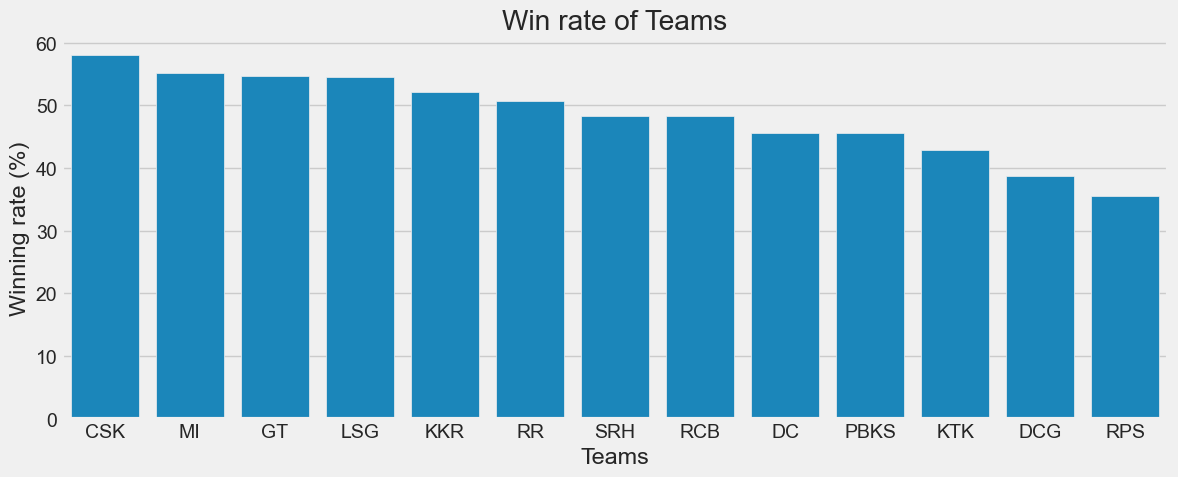

In [39]:
plt.figure(figsize=(12,5))
sns.barplot(x=win_df['team_code'], y=win_df['win_rate'])
plt.title('Win rate of Teams')
plt.xlabel('Teams')
plt.ylabel('Winning rate (%)')
plt.tight_layout()
plt.show()

### Q2 Most Title Wins

In [40]:
matches.groupby('season')[['season','winner']].tail(1)

,season,winner
57,2008,Rajasthan Royals
114,2009,Deccan Chargers
174,2010,Chennai Super Kings
247,2011,Chennai Super Kings
321,2012,Kolkata Knight Riders
397,2013,Mumbai Indians
457,2014,Kolkata Knight Riders
516,2015,Mumbai Indians
576,2016,Sunrisers Hyderabad
635,2017,Mumbai Indians


In [41]:
winner_count=matches.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()
winner_count

winner
Chennai Super Kings      5
Mumbai Indians           5
Kolkata Knight Riders    3
Deccan Chargers          1
Rajasthan Royals         1
Sunrisers Hyderabad      1
Gujarat Titans           1
Name: count, dtype: int64

In [42]:
winner_count = merge_short_names(winner_count, 'titles')

In [43]:
winner_count

,team_name,titles,team_code
0,Chennai Super Kings,5,CSK
1,Mumbai Indians,5,MI
2,Kolkata Knight Riders,3,KKR
3,Deccan Chargers,1,DCG
4,Rajasthan Royals,1,RR
5,Sunrisers Hyderabad,1,SRH
6,Gujarat Titans,1,GT


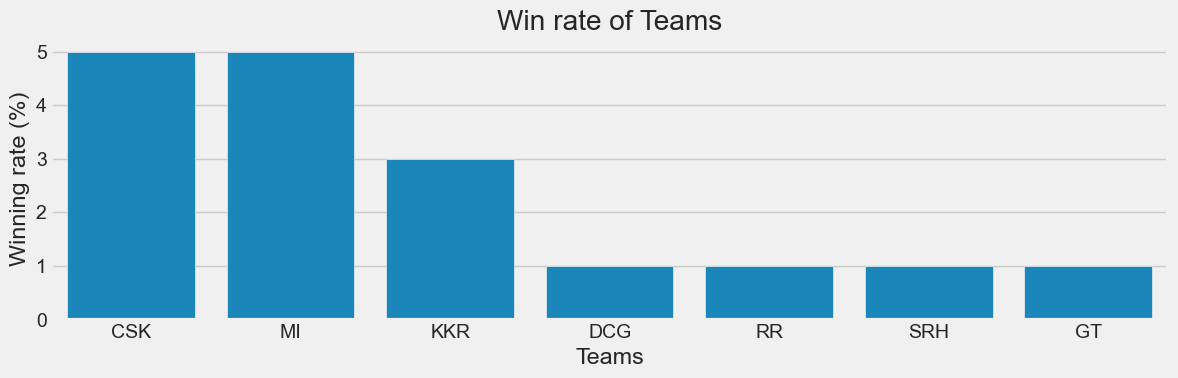

In [44]:
plt.figure(figsize=(12,4))
sns.barplot(x=winner_count['team_code'], y=winner_count['titles'])
plt.title('Win rate of Teams')
plt.xlabel('Teams')
plt.ylabel('Winning rate (%)')
plt.tight_layout()
plt.show()

### Q3 top 10 Players with most runs

In [45]:
runs=deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False)
runs.head()

batter
V Kohli      8014
S Dhawan     6769
RG Sharma    6630
DA Warner    6567
SK Raina     5536
Name: batsman_runs, dtype: int64

In [46]:
runs_df=runs.reset_index()
runs_df=runs_df.head(10)
runs_df

,batter,batsman_runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


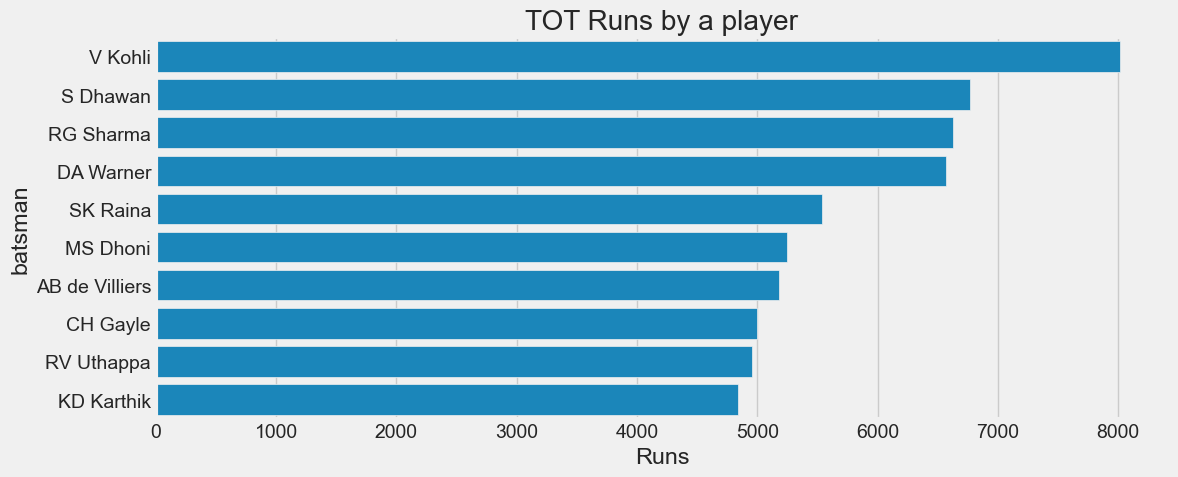

In [47]:
plt.figure(figsize=(12,5))
sns.barplot(x=runs_df['batsman_runs'], y=runs_df['batter'])
plt.title('TOT Runs by a player')
plt.xlabel('Runs')
plt.ylabel('batsman')
plt.tight_layout()
plt.show()

### Q4 top 10 Batting Performance

In [48]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


In [49]:
in_run=deliveries.groupby(['match_id','batter'])['batsman_runs'].sum().reset_index(name='Runs')
in_run=in_run.sort_values(by='Runs',ascending=False).head(10)
in_run

,match_id,batter,Runs
5302,598027,CH Gayle,175
2,335982,BB McCullum,158
14108,1304112,Q de Kock,140
7528,829795,AB de Villiers,133
11583,1216510,KL Rahul,132
15383,1370352,Shubman Gill,129
8359,980987,AB de Villiers,129
4687,548372,CH Gayle,128
10149,1136602,RR Pant,128
2237,419137,M Vijay,127


In [50]:
in_run['label'] = in_run['batter'] + ' (' + in_run['Runs'].astype(str) + ')'
in_run



,match_id,batter,Runs,label
5302,598027,CH Gayle,175,CH Gayle (175)
2,335982,BB McCullum,158,BB McCullum (158)
14108,1304112,Q de Kock,140,Q de Kock (140)
7528,829795,AB de Villiers,133,AB de Villiers (133)
11583,1216510,KL Rahul,132,KL Rahul (132)
15383,1370352,Shubman Gill,129,Shubman Gill (129)
8359,980987,AB de Villiers,129,AB de Villiers (129)
4687,548372,CH Gayle,128,CH Gayle (128)
10149,1136602,RR Pant,128,RR Pant (128)
2237,419137,M Vijay,127,M Vijay (127)


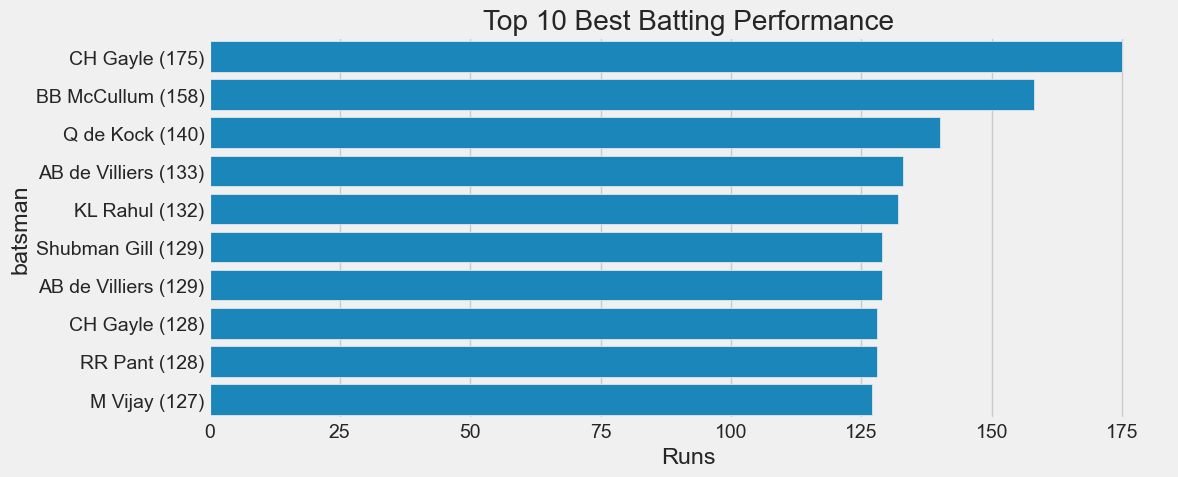

In [51]:
plt.figure(figsize=(12,5))
sns.barplot(x=in_run['Runs'], y=in_run['label'])
plt.title('Top 10 Best Batting Performance')
plt.xlabel('Runs')
plt.ylabel('batsman')
plt.tight_layout()
plt.show()

### Q5 Top 10 Strike Rate

In [52]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


In [53]:
runs=deliveries.groupby('batter')['batsman_runs'].sum()
ball=deliveries[deliveries['extras_type']!='wides'].groupby('batter').size()


In [54]:

# filter players with at least 100 balls
valid_batters = ball[ball >= 500].index

runs = runs[runs.index.isin(valid_batters)]
ball = ball[ball.index.isin(valid_batters)]

In [55]:
strike_rate=runs*100/ball
strike_rate=strike_rate.reset_index(name='Strike Rate')
strike_rate=strike_rate.sort_values(by='Strike Rate',ascending=False)
strike_rate_df=strike_rate.round(2).head(10)
strike_rate_df

,batter,Strike Rate
4,AD Russell,174.84
34,H Klaasen,168.31
100,SP Narine,165.84
56,LS Livingstone,162.46
71,N Pooran,162.00
88,RM Patidar,158.85
33,GJ Maxwell,156.70
115,V Sehwag,155.44
11,Abhishek Sharma,155.24
99,SO Hetmyer,153.08


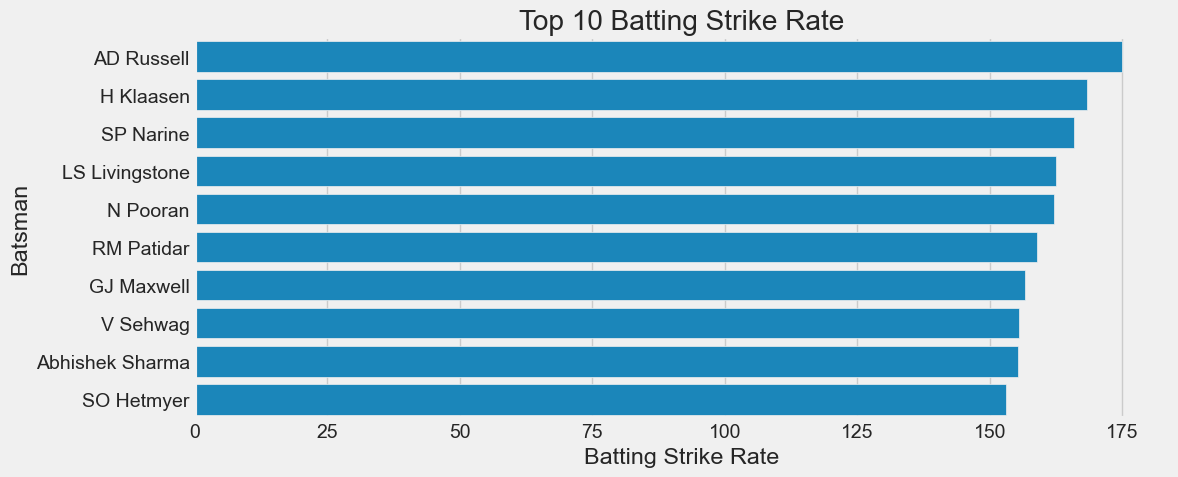

In [56]:
plt.figure(figsize=(12,5))
sns.barplot(x=strike_rate_df['Strike Rate'], y=strike_rate_df['batter'])
plt.title('Top 10 Batting Strike Rate')
plt.xlabel('Batting Strike Rate')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

### Q6 top 10 Best Bowling Strike rate

In [57]:
balls_bowled=deliveries[deliveries['extras_type']!='wides'].groupby('bowler').size()
balls_bowled

bowler
A Ashish Reddy     264
A Badoni            25
A Chandila         234
A Choudhary        102
A Dananjaya         24
                  ... 
Yash Dayal         583
Yash Thakur        407
Yudhvir Singh       72
Yuvraj Singh       870
Z Khan            2202
Length: 530, dtype: int64

In [58]:
wickets=deliveries[
    (~deliveries['dismissal_kind'].isna()) & 
    (~deliveries['dismissal_kind'].isin(['run out','retired hurt','obstructing the field']))
    ].groupby('bowler').size()
wickets

bowler
A Ashish Reddy     18
A Badoni            2
A Chandila         11
A Choudhary         5
A Flintoff          2
                 ... 
Yash Dayal         28
Yash Thakur        24
Yudhvir Singh       4
Yuvraj Singh       36
Z Khan            102
Length: 451, dtype: int64

In [59]:
valid_bowlers = balls_bowled[balls_bowled >= 500].index

balls_bowled = balls_bowled[balls_bowled.index.isin(valid_bowlers)]
wickets = wickets[wickets.index.isin(valid_bowlers)]

In [60]:
bowling=balls_bowled/wickets
bowling=bowling.reset_index(name='Bowling_SR')
bowling_sr=bowling.sort_values(by='Bowling_SR').head(10).round(2)
bowling_sr

,bowler,Bowling_SR
8,AD Russell,14.84
77,MR Marsh,15.22
53,K Rabada,15.33
23,DE Bollinger,15.62
93,PWH de Silva,15.77
40,Imran Tahir,16.06
34,HV Patel,16.13
69,MA Starc,16.35
9,AJ Tye,16.36
115,SL Malinga,16.74


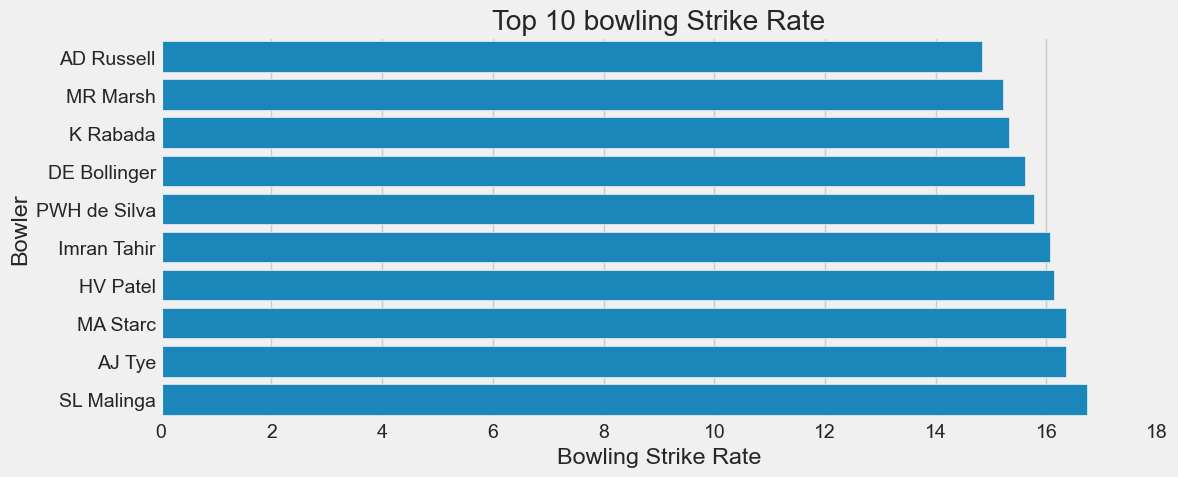

In [61]:
plt.figure(figsize=(12,5))
sns.barplot(x=bowling_sr['Bowling_SR'], y=bowling_sr['bowler'])
plt.title('Top 10 bowling Strike Rate')
plt.xlabel('Bowling Strike Rate')
plt.ylabel('Bowler')
plt.xlim(0,18)
plt.tight_layout()
plt.show()

### Q7 Top 10 Bowlers with highest Wickets

In [62]:
tot_wicket=['bowled','caught','lbw','stumped','caught and bowled','hit wicket']
wickets=deliveries[deliveries['dismissal_kind'].isin(tot_wicket)]
wickets=wickets.groupby('bowler').size()
wickets_df = wickets.reset_index(name='Wickets')
wickets_df = wickets_df.sort_values(by='Wickets', ascending=False).head(10)
wickets_df

,bowler,Wickets
445,YS Chahal,205
297,PP Chawla,192
102,DJ Bravo,183
61,B Kumar,181
304,R Ashwin,180
379,SP Narine,180
7,A Mishra,174
372,SL Malinga,170
168,JJ Bumrah,168
319,RA Jadeja,160


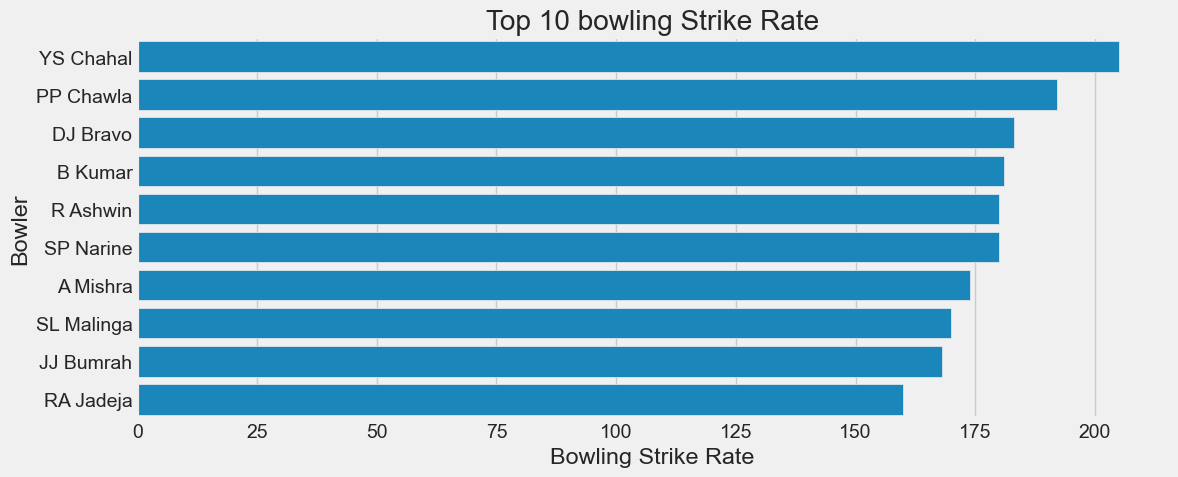

In [63]:
plt.figure(figsize=(12,5))
sns.barplot(x=wickets_df['Wickets'], y=wickets_df['bowler'])
plt.title('Top 10 bowling Strike Rate')
plt.xlabel('Bowling Strike Rate')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

### Q8 best batting partnerships

In [64]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


In [65]:
deliveries['pair'] = deliveries[['batter','non_striker']].apply(
    lambda x: tuple(sorted(x)), axis=1
)


partnership = deliveries.groupby(['match_id','pair'])['batsman_runs'].sum()
partnership = partnership.reset_index(name='Runs')
partnership = partnership.sort_values(by='Runs', ascending=False).head(10)

partnership['batter1'] = partnership['pair'].apply(lambda x: x[0])
partnership['batter2'] = partnership['pair'].apply(lambda x: x[1])


partnership['runs1'] = partnership.apply(
    lambda x: deliveries[
        (deliveries['match_id'] == x['match_id']) &
        (deliveries['pair'] == x['pair']) &
        (deliveries['batter'] == x['batter1'])
    ]['batsman_runs'].sum(),
axis=1
)

partnership['runs2'] = partnership.apply(
    lambda x: deliveries[
        (deliveries['match_id'] == x['match_id']) &
        (deliveries['pair'] == x['pair']) &
        (deliveries['batter'] == x['batter2'])
    ]['batsman_runs'].sum(),
axis=1
)


partnership['label'] = partnership.apply(
    lambda x: f"{x['batter1']} – {x['batter2']} ({x['Runs']})",
axis=1
)

partnership = partnership.sort_values('Runs', ascending=True).reset_index(drop=True)


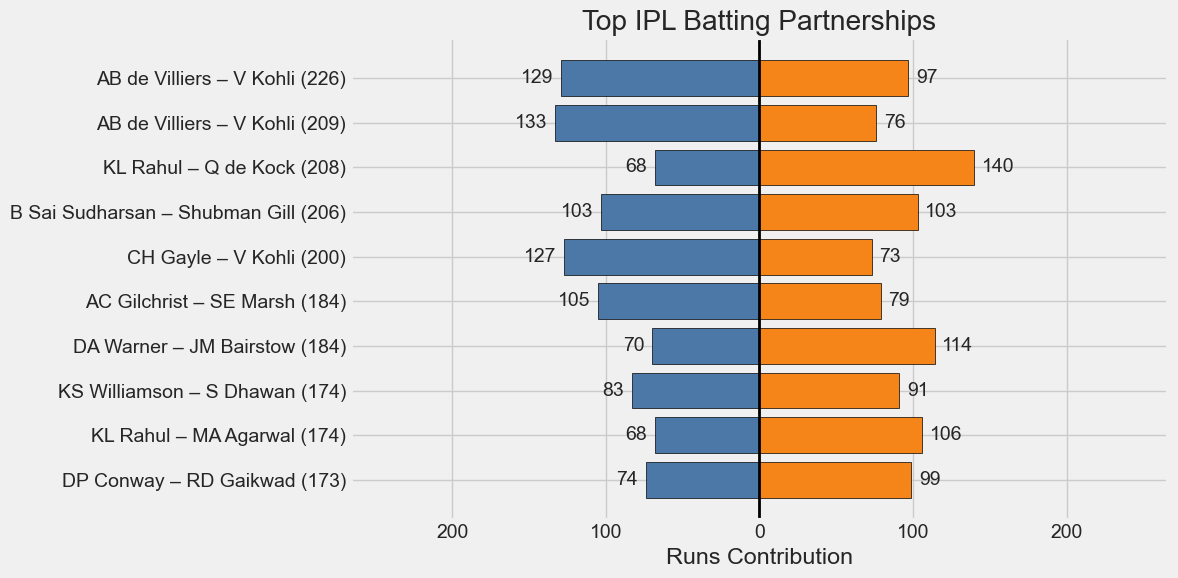

In [66]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,6))

plt.barh(partnership['label'], -partnership['runs1'],
         color='#4C78A8', edgecolor='black')

plt.barh(partnership['label'], partnership['runs2'],
         color='#F58518', edgecolor='black')

plt.axvline(0, color='black', linewidth=2)

limit = partnership['Runs'].max() + 40
plt.xlim(-limit, limit)

# Show positive numbers on both sides of x-axis
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{abs(int(x))}')
)

plt.title("Top IPL Batting Partnerships")
plt.xlabel("Runs Contribution")

# Add value labels on bars
for i, row in partnership.iterrows():

    plt.text(-row['runs1'] - 5, i, int(row['runs1']),
             va='center', ha='right')

    plt.text(row['runs2'] + 5, i, int(row['runs2']),
             va='center', ha='left')

plt.tight_layout()
plt.show()

### Q9 Batsman with most amount of six

In [67]:
most_six=deliveries[deliveries['batsman_runs']==6].groupby('batter').size()
most_six=most_six.sort_values(ascending=False)
most_six=most_six.reset_index(name='no of six').head(10)
most_six

,batter,no of six
0,CH Gayle,359
1,RG Sharma,281
2,V Kohli,273
3,AB de Villiers,253
4,MS Dhoni,252
5,DA Warner,236
6,KA Pollard,224
7,AD Russell,209
8,SV Samson,206
9,SK Raina,204


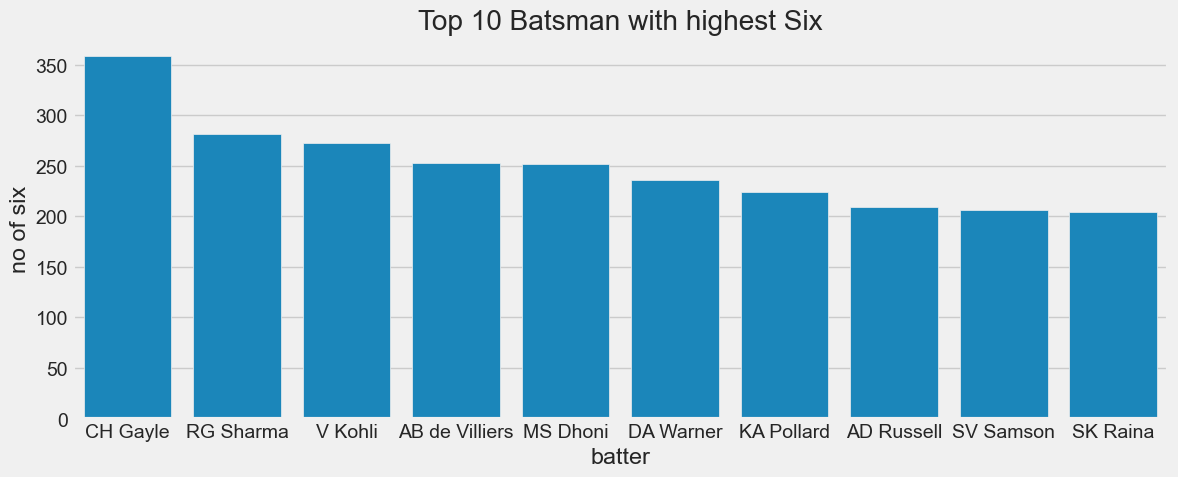

In [68]:
plt.figure(figsize=(12,5))
sns.barplot(x=most_six['batter'], y=most_six['no of six'])
plt.title('Top 10 Batsman with highest Six')
plt.xlabel('batter')
plt.ylabel('no of six')
plt.tight_layout()
plt.show()

### Q10 Batsman with Most amount of Fours

In [69]:
most_four=deliveries[deliveries['batsman_runs']==4].groupby('batter').size()
most_four=most_four.sort_values(ascending=False)
most_four=most_four.reset_index(name='no of four').head(10)
most_four

,batter,no of four
0,S Dhawan,768
1,V Kohli,708
2,DA Warner,663
3,RG Sharma,599
4,SK Raina,506
5,G Gambhir,492
6,RV Uthappa,481
7,AM Rahane,479
8,KD Karthik,466
9,F du Plessis,422


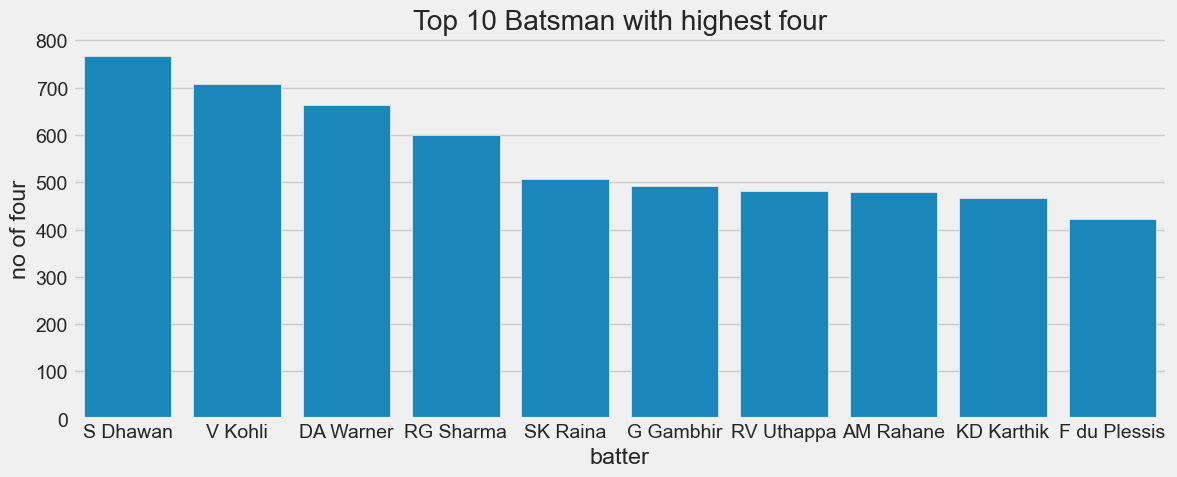

In [70]:
plt.figure(figsize=(12,5))
sns.barplot(x=most_four['batter'], y=most_four['no of four'])
plt.title('Top 10 Batsman with highest four')
plt.xlabel('batter')
plt.ylabel('no of four')
plt.tight_layout()
plt.show()

### Q11 Venues with Most Runs

In [71]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,pair
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,"(BB McCullum, SC Ganguly)"


In [72]:
matches.head(1)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,NaN,Non D/L,Asad Rauf,RE Koertzen


In [73]:
matches_runs=deliveries.merge(matches[['id','venue']], left_on = 'match_id',right_on='id')
venue_runs=matches_runs.groupby('venue')['batsman_runs'].sum()
venue_runs=venue_runs.sort_values(ascending=False).head(10)
venue_runs

venue
Eden Gardens                                  22443
Wankhede Stadium                              22175
M Chinnaswamy Stadium                         19139
Feroz Shah Kotla                              17499
Wankhede Stadium, Mumbai                      14744
MA Chidambaram Stadium, Chepauk               14472
Rajiv Gandhi International Stadium, Uppal     14179
Dubai International Cricket Stadium           13753
Sawai Mansingh Stadium                        13473
Punjab Cricket Association Stadium, Mohali    10421
Name: batsman_runs, dtype: int64

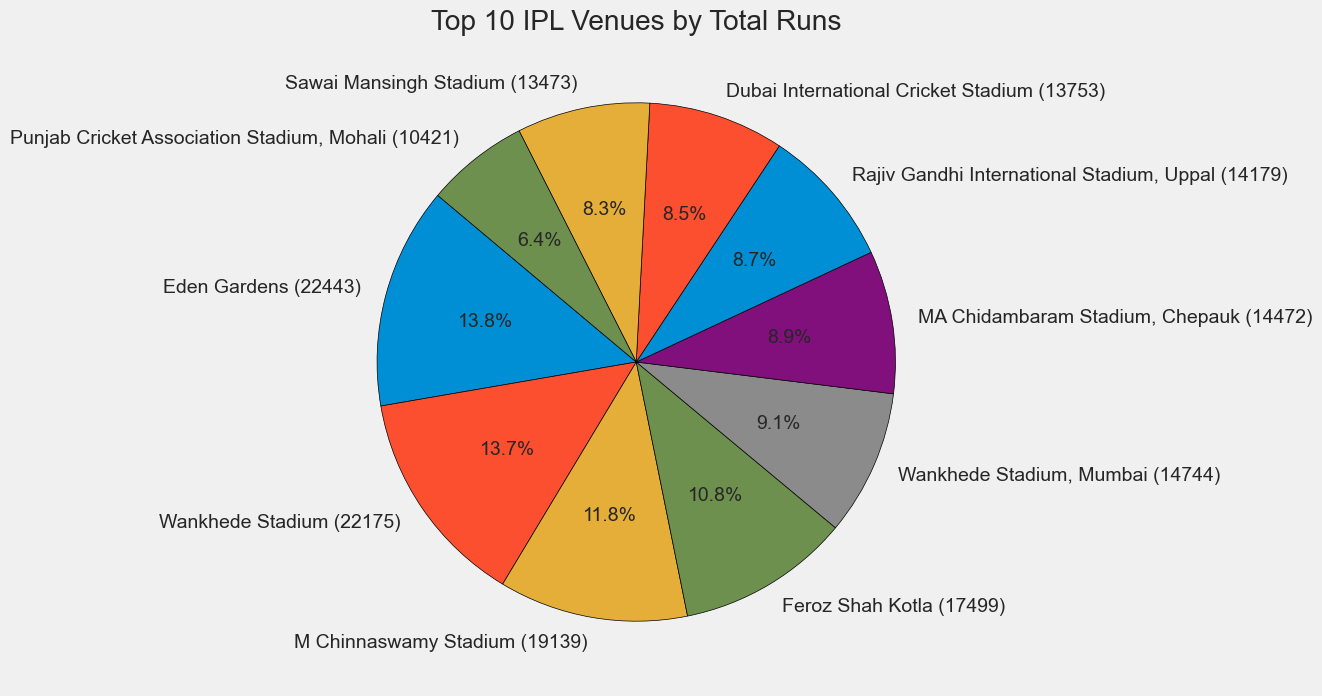

In [74]:
labels = [f"{venue} ({runs})" for venue, runs in zip(venue_runs.index, venue_runs)]

plt.figure(figsize=(8,8))

plt.pie(
    venue_runs,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor':'black'}
)

plt.title('Top 10 IPL Venues by Total Runs')

plt.show()

### Q12  IPL best all rounders

In [75]:
all_rounders= strike_rate.merge(bowling, left_on='batter',right_on='bowler')
all_rounders.head(2)

,batter,Strike Rate,bowler,Bowling_SR
0,AD Russell,174.841883,AD Russell,14.843478
1,SP Narine,165.837838,SP Narine,22.694444


In [76]:
all_rounders['all_rounder']=(all_rounders['Strike Rate']/all_rounders['Bowling_SR'])
all_rounders=all_rounders.sort_values(by='all_rounder',ascending=False).head(10)
all_rounders=all_rounders.round(2)
all_rounders

,batter,Strike Rate,bowler,Bowling_SR,all_rounder
0,AD Russell,174.84,AD Russell,14.84,11.78
24,MR Marsh,127.64,MR Marsh,15.22,8.39
7,MP Stoinis,142.01,MP Stoinis,18.70,7.60
22,DJ Bravo,129.57,DJ Bravo,17.10,7.58
1,SP Narine,165.84,SP Narine,22.69,7.31
8,JA Morkel,141.92,JA Morkel,20.42,6.95
4,KA Pollard,147.57,KA Pollard,21.68,6.81
13,SM Curran,136.48,SM Curran,20.48,6.66
5,HH Pandya,145.72,HH Pandya,22.23,6.55
9,MM Ali,141.53,MM Ali,21.69,6.53


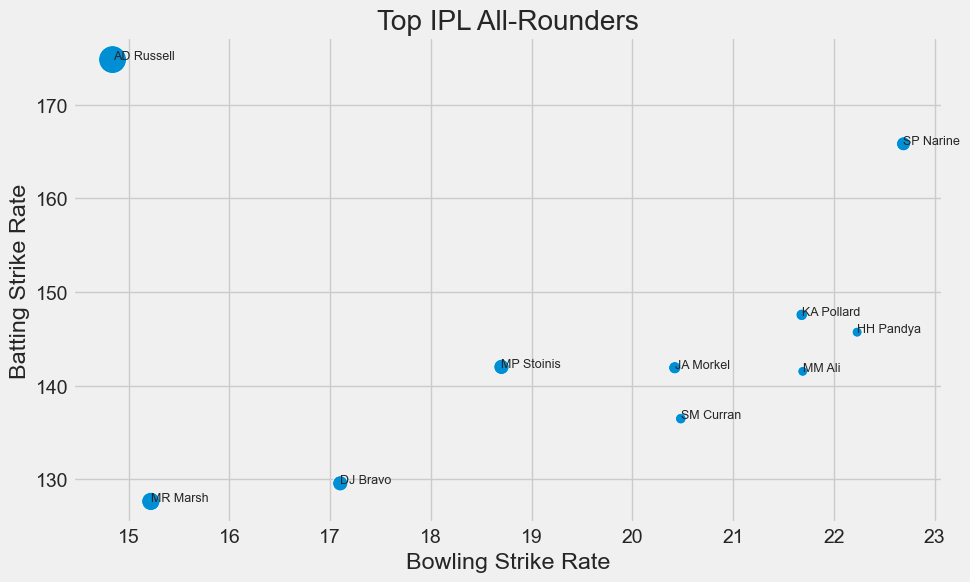

In [77]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=all_rounders,
                x='Bowling_SR',
                y='Strike Rate',
                size='all_rounder',
                sizes=(50,400),
                legend=False)

for _, row in all_rounders.iterrows():
    plt.text(
        row['Bowling_SR'],
        row['Strike Rate'],
        row['batter'],
        fontsize=9
    )

plt.title('Top IPL All-Rounders')
plt.xlabel('Bowling Strike Rate')
plt.ylabel('Batting Strike Rate')

plt.show()

### Q13 best Death Over Hitters

In [78]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,pair
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,"(BB McCullum, SC Ganguly)"


In [79]:
death_over_balls=deliveries[(deliveries['over']>=16) & (deliveries['extras_type']!='wides')].groupby('batter').size()
death_over_runs=deliveries[deliveries['over']>=16].groupby('batter')['batsman_runs'].sum()
death_over=(death_over_runs*100/death_over_balls).reset_index(name='strike_rate')
death_over

,batter,strike_rate
0,A Ashish Reddy,151.181102
1,A Badoni,171.134021
2,A Chandila,57.142857
3,A Choudhary,126.315789
4,A Dananjaya,80.000000
...,...,...
578,Yash Dayal,0.000000
579,Yashpal Singh,110.000000
580,Yudhvir Singh,33.333333
581,Yuvraj Singh,178.338279


In [80]:
death_over['runs'] = death_over_runs.values


death_over = death_over[death_over['runs'] >= 500]

death_over = death_over.sort_values(by='strike_rate', ascending=False)

death_over=death_over.head(10)

In [81]:
death_over

,batter,strike_rate,runs
24,AB de Villiers,232.569558,1421
432,RR Pant,207.284768,626
31,AD Russell,203.632887,1065
550,V Kohli,200.914077,1099
488,SO Hetmyer,197.674419,680
421,RG Sharma,196.655518,1176
500,SV Samson,194.661922,547
464,SA Yadav,191.821561,516
328,MS Dhoni,189.009498,2786
132,DJ Bravo,187.353630,800


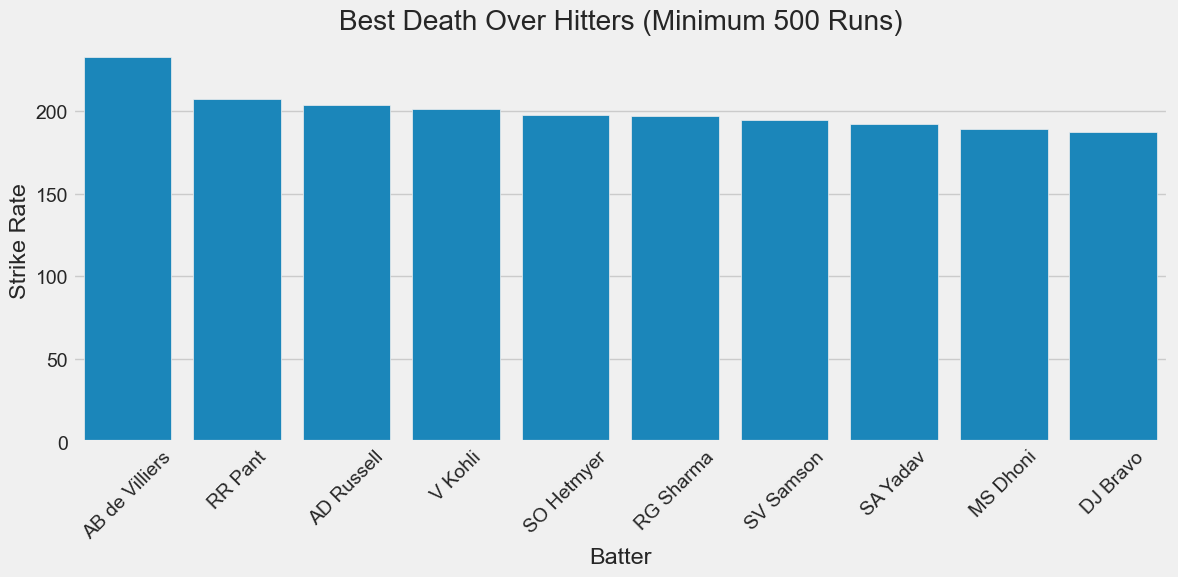

In [82]:
plt.figure(figsize=(12,6))
sns.barplot(data=death_over, x='batter', y='strike_rate')
plt.title('Best Death Over Hitters (Minimum 500 Runs)')
plt.xlabel('Batter')
plt.ylabel('Strike Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Q14 best power play strike rate

In [83]:
power_play_balls=deliveries[(deliveries['over']<=5) & (deliveries['extras_type']!='wides')].groupby('batter').size()
power_play_runs=deliveries[deliveries['over']<=5].groupby('batter')['batsman_runs'].sum()
power_play=(power_play_runs*100/power_play_balls).reset_index(name='strike_rate')
power_play

,batter,strike_rate
0,A Ashish Reddy,83.333333
1,A Badoni,48.648649
2,A Chopra,69.230769
3,A Flintoff,107.692308
4,A Manohar,66.666667
...,...,...
357,YV Takawale,91.666667
358,Yashpal Singh,47.222222
359,Younis Khan,42.857143
360,Yuvraj Singh,103.763441


In [84]:
power_play['runs'] = power_play_runs.values


power_play = power_play[power_play['runs'] >= 500]

power_play  = power_play .sort_values(by='strike_rate', ascending=False)

power_play =power_play .head(10)

In [85]:
power_play

,batter,strike_rate,runs
298,SP Narine,171.376812,946
40,Abhishek Sharma,157.261411,758
354,YBK Jaiswal,152.647504,1009
133,JM Bairstow,147.189097,864
237,PP Shaw,146.572361,1347
65,CA Lynn,144.259259,779
338,V Sehwag,144.162896,1593
250,RA Tripathi,140.981241,977
280,SA Yadav,140.819672,859
126,JC Buttler,140.750436,1613


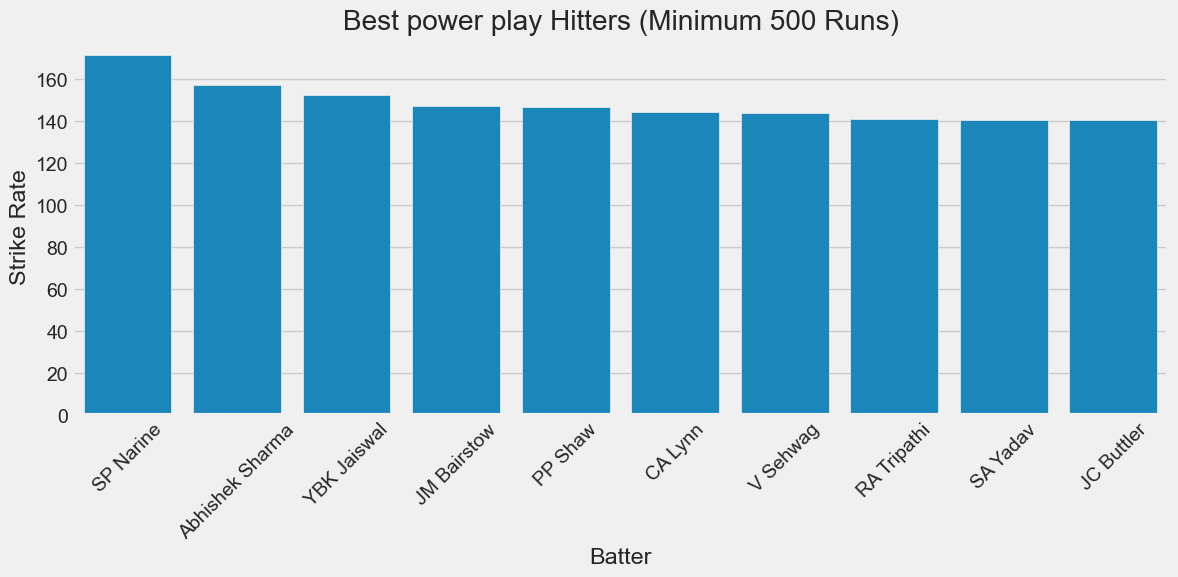

In [86]:
plt.figure(figsize=(12,6))
sns.barplot(data=power_play, x='batter', y='strike_rate')
plt.title('Best power play Hitters (Minimum 500 Runs)')
plt.xlabel('Batter')
plt.ylabel('Strike Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Q15 Top batters Striker rate in diff match Phases

In [88]:
top_players=runs_df['batter'].head(5).tolist()
phase_df=deliveries[deliveries['batter'].isin(top_players)].copy()

In [90]:
phase_df=phase_df[phase_df['extras_type']!='wides']
phase_df['phase']=phase_df['over'].apply(lambda x: 'Powerplay' if x<=6 else ('Middle overs' if x<=15 else 'Death overs'))

In [92]:
run_phase=phase_df.groupby(['batter','phase'])['batsman_runs'].sum()
ball_phase=phase_df.groupby(['batter','phase']).size()
strike_rate=(run_phase*100/ball_phase).reset_index(name='strike_rate')

In [94]:
strike_rate=strike_rate.sort_values(by='batter')
strike_rate

,batter,phase,strike_rate
0,DA Warner,Death overs,178.111588
1,DA Warner,Middle overs,140.674157
2,DA Warner,Powerplay,135.663816
3,RG Sharma,Death overs,196.655518
4,RG Sharma,Middle overs,124.463696
5,RG Sharma,Powerplay,119.754300
6,S Dhawan,Death overs,164.686469
7,S Dhawan,Middle overs,130.644316
8,S Dhawan,Powerplay,121.258831
9,SK Raina,Death overs,170.694087


In [99]:
phase_order = ['Powerplay', 'Middle overs', 'Death overs']
strike_rate['phase'] = pd.Categorical(strike_rate['phase'], categories=phase_order, ordered=True)

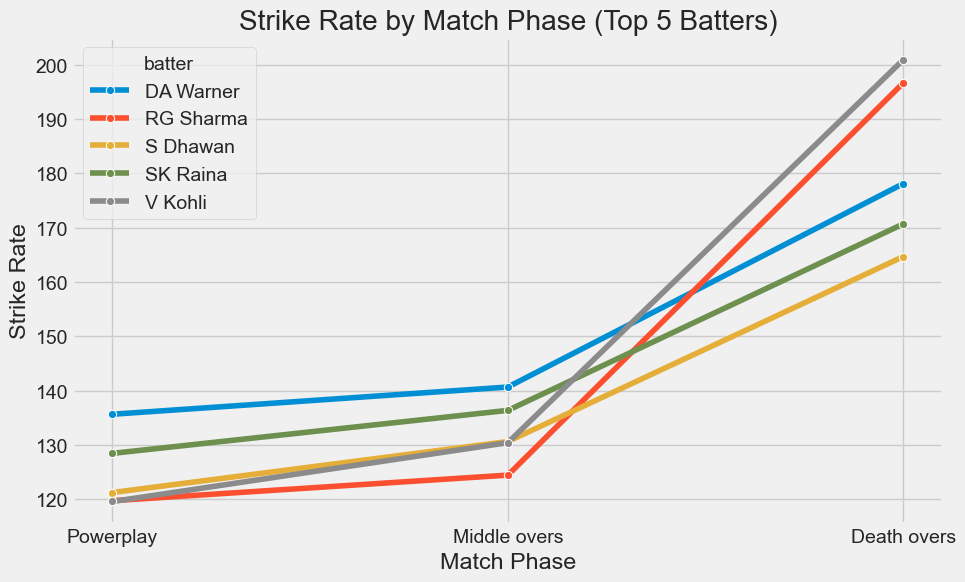

In [100]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=strike_rate,
    x='phase',
    y='strike_rate',
    hue='batter',
    marker='o'
)
plt.title('Strike Rate by Match Phase (Top 5 Batters)')
plt.xlabel('Match Phase')
plt.ylabel('Strike Rate')

plt.show()

### Q 16 best strike rate players strike rate during diff match phases

In [102]:
high_strike_players=strike_rate_df['batter'].head(5).tolist()
phase_df=deliveries[deliveries['batter'].isin(high_strike_players)].copy()

In [103]:
phase_df=phase_df[phase_df['extras_type']!='wides']
phase_df['phase']=phase_df['over'].apply(lambda x: 'Powerplay' if x<=6 else ('Middle overs' if x<=15 else 'Death overs'))

In [104]:
run_phase=phase_df.groupby(['batter','phase'])['batsman_runs'].sum()
ball_phase=phase_df.groupby(['batter','phase']).size()
strike_rate=(run_phase*100/ball_phase).reset_index(name='strike_rate')

In [105]:
strike_rate=strike_rate.sort_values(by='batter')
strike_rate

,batter,phase,strike_rate
0,AD Russell,Death overs,203.632887
1,AD Russell,Middle overs,156.407323
2,AD Russell,Powerplay,215.384615
3,H Klaasen,Death overs,197.419355
4,H Klaasen,Middle overs,159.947644
5,H Klaasen,Powerplay,143.396226
6,LS Livingstone,Death overs,217.021277
7,LS Livingstone,Middle overs,154.647887
8,LS Livingstone,Powerplay,144.186047
9,N Pooran,Death overs,170.476190


In [106]:
phase_order = ['Powerplay', 'Middle overs', 'Death overs']
strike_rate['phase'] = pd.Categorical(strike_rate['phase'], categories=phase_order, ordered=True)

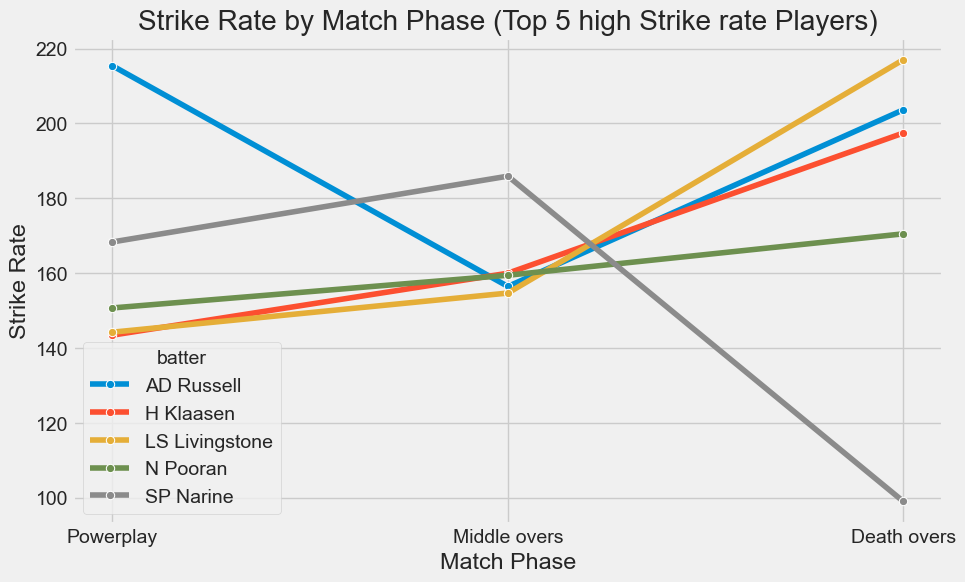

In [107]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=strike_rate,
    x='phase',
    y='strike_rate',
    hue='batter',
    marker='o'
)
plt.title('Strike Rate by Match Phase (Top 5 high Strike rate Players)')
plt.xlabel('Match Phase')
plt.ylabel('Strike Rate')

plt.show()